# Carousel 🎠
### Rotate into whichever sectors are hottest. Does chasing the leaders beat just owning them all?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats the basket?: Not supported](https://img.shields.io/badge/Beats_the_basket%3F-Not_supported-8b949e?style=flat-square)

Sector rotation is the strategy your uncle explains over Thanksgiving: tech is leading, so buy tech; energy is rolling over, so dump it; keep spinning into whatever's hot. The premise is **sector momentum** — a sector that's been winning keeps winning (Moskowitz–Grinblatt 1999). It feels obviously smart. But there's a quiet benchmark it has to clear: just holding *all* the sectors, equal-weight, and never trading.

This is the desk's eleventh idea from Kakushadze & Serur's *151 Trading Strategies* (strategy §4.1). We prove the engine on a synthetic market where sector momentum is baked in (and a null), then run the real SPDR sector ETFs — and find the carousel spins you right back to where you started, minus the cost of the ride.

> 📓 **Plain-language layer.** The alpha-over-the-basket, the long-short factor *t* and the top-k sweep are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it; the core runs on a **synthetic** panel, so the real-sector numbers (from [`../docs/results.md`](../docs/results.md)) are a measurement. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from carousel import data, rotation, strategy, decompose, extension

# Offline synthetic sectors: a MOMENTUM panel (leaders persist) and a no-momentum NULL. The real SPDR
# verdict is in ../docs/results.md.
panel,  truth = data.synthetic_sectors(mom_strength=0.0011, seed=28)   # the momentum panel
panel0, _     = data.synthetic_sectors(mom_strength=0.0,    seed=28)   # the null
print(f"{truth.n_sectors} synthetic sectors x {truth.n_bars} days | baked mom_strength={truth.mom_strength} | null=0")


11 synthetic sectors x 4032 days | baked mom_strength=0.0011 | null=0


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Does the hot sector stay hot? | 🟡 **Not enough to matter** — the real-sector long-short momentum factor is flat-to-negative (**-1.5%/yr**, *t* **-0.5**). |
| Does rotation beat holding all sectors? | 🚫 **No** — Sharpe **+0.43** vs the basket's **+0.45** (gain **-0.02**), alpha over the basket *t* = **+0.3**. |
| Is it at least robust? | ⚪ **No** — it beats the basket on only **33%** of "how-many-sectors" choices, a coin flip. |

> Desk shorthand: **Signal `WEAK` · Tradability `MIRAGE` · Beats the basket? `NOT SUPPORTED`** — concentration risk and turnover, for nothing.

## 1 · The claim 📣

Rank the sectors by their trailing return, hold the top few, refresh monthly. The claim is that the leaders keep leading. On our synthetic market we baked exactly that in — sort by momentum and the top sectors out-earn the bottom over the next month:

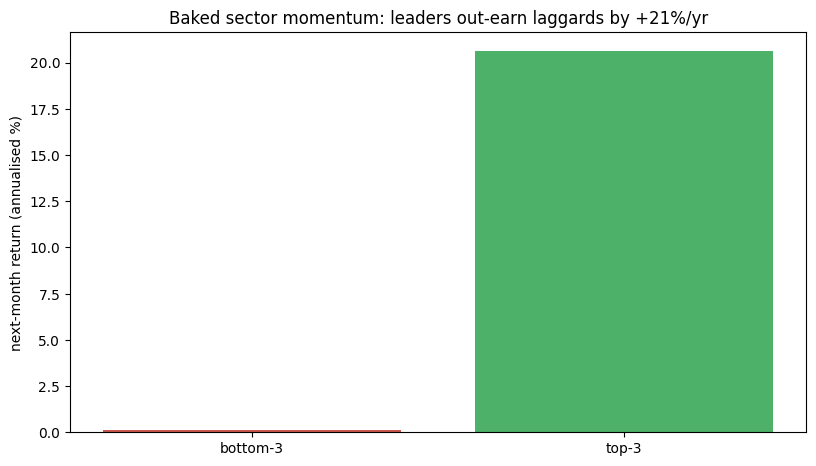

In [2]:
rs = rotation.rotation_strength(panel)
fig, ax = plt.subplots()
ax.bar(['bottom-3', 'top-3'], [rs['bottom_ann_pct'], rs['top_ann_pct']], color=['#c0392b','#2ea44f'], alpha=.85)
ax.set_ylabel('next-month return (annualised %)')
ax.set_title(f"Baked sector momentum: leaders out-earn laggards by {rs['top_minus_bottom_ann_pct']:+.0f}%/yr")
plt.show()

## 2 · So what? 💰

If sector momentum were real and harvestable, rotation would be a cheap, liquid way to beat the market — every robo-advisor and tactical-allocation fund would (and does) sell it. But concentrating into a few sectors is a *cost*: more idiosyncratic risk, more turnover, more drawdown when the hot sector turns. The only honest question is whether the momentum pays more than that diversification you gave up.

## 3 · How we'd know 🔬

Three checks:

1. **Does the hot sector stay hot?** The top-minus-bottom momentum spread and its *t*.
2. **Does rotation beat the equal-weight basket** (alpha over it, net of cost)?
3. **Does it generalise** across how many sectors you hold? And the **null:** no persistence ⇒ no edge.

**Mirage line:** rotation ties (or loses to) the basket, the long-short factor is insignificant, and the win is one cherry-picked concentration.

## 4 · The teardown 🔧

### 4a · Momentum tape vs the null
Run rotation on both synthetic panels, against the equal-weight basket.

In [3]:
for label, p in [('momentum', panel), ('null', panel0)]:
    cmp = strategy.compare(p, cost_bps=3.0); a = decompose.vs_equal_weight(p, cost_bps=3.0)
    print(f"{label:9s}: rotation Sharpe {cmp['rotation']['sharpe']:+.2f} vs basket {cmp['equal_weight']['sharpe']:+.2f} "
          f"(gain {cmp['rotation_minus_ew_sharpe']:+.2f}), alpha {a['alpha_ann_pct']:+.1f}%/yr (HAC t {a['alpha_t']:+.1f})")

momentum : rotation Sharpe +1.26 vs basket +0.64 (gain +0.62), alpha +10.1%/yr (HAC t +7.6)


null     : rotation Sharpe +0.58 vs basket +0.65 (gain -0.07), alpha -0.7%/yr (HAC t -0.6)


### 4b · On the real market — the carousel goes nowhere
On the 11 real SPDR sectors (quoted from [`../docs/results.md`](../docs/results.md)):

- Rotation Sharpe **+0.43** vs the equal-weight basket **+0.45** — a gain of **-0.02**, i.e. *worse*.
- Alpha over the basket **+0.4%/yr** (*t* **+0.3**), beta **0.92** — you basically held the market with extra steps.
- The pure sector-momentum factor is **-1.5%/yr** (*t* **-0.5**) — no premium.
- And it churns **7.3×/yr** for the privilege.

## 5 · The verdict 🧾

- **No sector-momentum premium** — long-short factor -1.5%/yr (*t* -0.5).
- **Doesn't beat the basket** — gain -0.02, alpha *t* +0.3.
- **Doesn't generalise** — beats the basket on 33% of top-k choices.

> **Signal `WEAK` · Tradability `MIRAGE` · Beats the basket? `NOT SUPPORTED`.** The carousel spins; you end up where you started, lighter by the cost of the ride.

## 6 · Could you trade it? 💸

- **It ties the do-nothing basket** before you even worry about taxes on **7.3×/yr** turnover.
- **You paid in risk** — a 3-sector book is far more concentrated than holding all 11, for no return.
- **The 'winning' setup is hindsight** — change how many sectors you hold and the edge vanishes.

> Tradability **`MIRAGE`**; the top-k sweep ([`../docs/extension.md`](../docs/extension.md)) shows the cherry-pick.

## 7 · Going further 🚪

- **The top-k sweep** (beat 7 of the quants notebook + [`../docs/extension.md`](../docs/extension.md)): rotation's gain over the basket across the number of sectors held — a coin flip.
- **A bigger, finer universe.** 11 sectors is a tiny cross-section; sector momentum is studied on industries (49 Fama-French industries). Does it survive there, where the diversity is real?
- **Dual momentum** (absolute + relative): only rotate when the leaders also beat cash — does the trend filter add anything, or just more parameters?

PRs welcome — give rotation a real cross-section, or find the variant that beats buy-the-basket out of sample.